In [4]:
from mtflearn import ZPs

In [20]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


class FixedConvLayer(nn.Module):
    def __init__(self, kernels: torch.Tensor, stride=1):
        super(FixedConvLayer, self).__init__()
        assert kernels.shape[1] % 2 == 1 and kernels.shape[2] % 2 == 1, "Kernel size must be odd to preserve input shape."
        self.register_buffer('kernels', kernels.unsqueeze(1))  # Shape becomes (N, 1, H, W)
        self.stride = stride
        self.kernel_size = (kernels.shape[1], kernels.shape[2])  # (H, W)
        self.padding = ((self.kernel_size[0] - 1) // 2, (self.kernel_size[1] - 1) // 2)  # (pad_H, pad_W)
        self.norm_factor = 4./(self.kernel_size[0] * self.kernel_size[1]) / np.pi  # normalizingh factor

    def forward(self, x):
        if x.dim() == 2:  # Single image case (H, W)
            x = x.unsqueeze(0).unsqueeze(0)  # Shape becomes (1, 1, H, W)
        elif x.dim() == 3:  # Stack of images (num_imgs, H, W)
            x = x.unsqueeze(1)  # Shape becomes (num_imgs, 1, H, W)
        else:
            raise ValueError("Input must be of shape (H, W) or (num_imgs, H, W)")

        x1 = self.norm_factor * F.conv2d(x, self.kernels, stride=self.stride, padding=self.padding)
        return x1
    
    def forward_(self, x):
        x = x.unsqueeze(0).unsqueeze(0)  # Shape becomes (1, 1, H, W)
        x1 = self.norm_factor * F.conv2d(x, self.kernels, stride=self.stride, padding=self.padding).squeeze(0)

        return x3

## load skiamge data

In [21]:
import numpy as np
from skimage.data import camera

img = camera()
img = img / img.max()

# load zps kernels

In [22]:
from mtflearn import ZPs

n_max = 10
size = 45
zps = ZPs(n_max=10, size=size)

# zps_data is a 3D numpy array with a shape of (N, size, size), where N is the total number of Zernike polynomial, if n_max = 10, N = 66
kernels = zps.polynomials.astype(np.float32)
print(kernels.shape)

(66, 45, 45)


In [23]:
ps = np.array([img[256-22:256+23, 256-22:256+23],])
m = zps.fit_transform(ps)
# m is a zmoments object
print(m)
# m.data is a numpy array
print(m.data.shape)

(1, 66)


## try torch

In [24]:
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [25]:
# Example usage:

# numpy array to tensor
torch_kernels = torch.from_numpy(kernels).float().to(device)
torch_img = torch.from_numpy(img).float().to(device)

fixed_conv = FixedConvLayer(torch_kernels).to(device)

output = fixed_conv(torch_img)
print(output.shape)  # Should be (N, H, W) -> (2, 5, 5) with padding ensuring input size is preserved

torch.Size([1, 66, 512, 512])


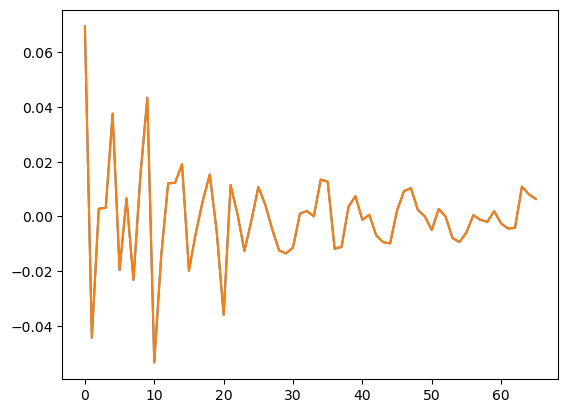

In [26]:
import matplotlib.pyplot as plt 
plt.plot(output[0, :, 256, 256].cpu())
plt.plot(m.data.ravel())